<a href="https://colab.research.google.com/github/Girawale-Sanket/Time-Series-Assignment/blob/main/TSA_LAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [16]:
data=pd.read_csv('/content/Bhubaneshwer_data.csv')

In [17]:
data.head()

,Calendar Day,Sales Qty 5Y
0,11-10-2017,0.5
1,12-10-2017,0.5
2,23-11-2017,0.5
3,24-11-2017,0.5
4,06-12-2017,1.0


In [18]:
data.shape

(706, 2)

In [19]:
data.isnull().sum()

,0
Calendar Day,0
Sales Qty 5Y,0


In [20]:
data.describe()

,Sales Qty 5Y
count,706.000000
mean,9.314589
std,9.371686
min,0.050000
25%,2.668750
50%,6.500000
75%,12.500000
max,59.600000


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Calendar Day  706 non-null    object 
 1   Sales Qty 5Y  706 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.2+ KB


In [22]:
from datetime import datetime

In [23]:
data['Calendar Day'] = pd.to_datetime(data['Calendar Day'], format='%d-%m-%Y')

In [24]:
data['Calendar Day'].dtype

dtype('<M8[ns]')

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Calendar Day  706 non-null    datetime64[ns]
 1   Sales Qty 5Y  706 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.2 KB


In [26]:
data.set_index("Calendar Day", inplace=True)

In [27]:
data.head()

,Sales Qty 5Y
Calendar Day,
2017-10-11,0.5
2017-10-12,0.5
2017-11-23,0.5
2017-11-24,0.5
2017-12-06,1.0


In [28]:
#sorting
data = data.sort_values("Calendar Day")
data.head()

,Sales Qty 5Y
Calendar Day,
2017-10-11,0.5
2017-10-12,0.5
2017-11-23,0.5
2017-11-24,0.5
2017-12-06,1.0


In [30]:
Y=data['Sales Qty 5Y'].resample('MS').mean()
Y
#MS= MainSheet or Master Data View

,Sales Qty 5Y
Calendar Day,
2017-10-01,0.500000
2017-11-01,0.500000
2017-12-01,13.388889
2018-01-01,8.187500
2018-02-01,21.000000
2018-03-01,NaN
2018-04-01,3.135714
2018-05-01,6.990000
2018-06-01,6.861538


In [31]:
Y.fillna(0, inplace=True)

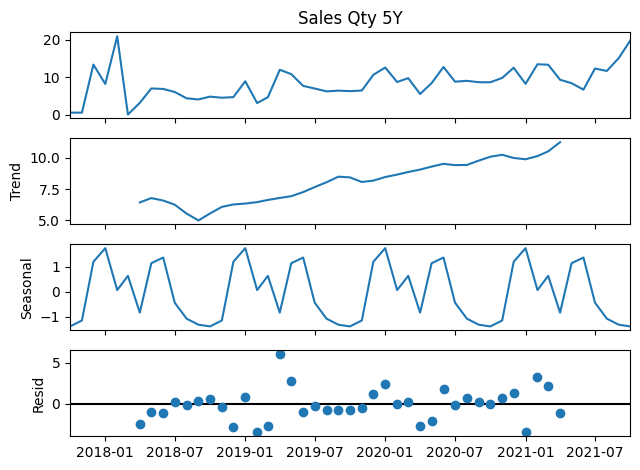

In [33]:
from pylab import rcParams
decomposition = seasonal_decompose(Y, model='additive')
fig = decomposition.plot()
plt.show()

In [34]:
for lag in range(1,11):
  print('Lag', lag, ':', Y.corr(Y.shift(lag)))

Lag 1 : 0.26714045703251565
Lag 2 : 0.1497124016652784
Lag 3 : -0.012633537887459512
Lag 4 : 0.01787925385232892
Lag 5 : 0.35495362125031626
Lag 6 : 0.2841612409345628
Lag 7 : 0.2536388479780158
Lag 8 : 0.2810224349867042
Lag 9 : 0.20512102422231152
Lag 10 : 0.16333673292517883
